# Regresión Lineal con Redes Neuronales
**Dataset:** Industria Florícola - Precio de Exportación vs Diámetro de Rosas Amarillas

En este notebook aplicaré una red neuronal para resolver un problema real del sector agroindustrial y de exportación. El objetivo es predecir el **Precio de Exportación (en USD por caja)** de rosas amarillas categoría Premium, Utilizando como atributo matemático principal el **Diámetro Promedio que tiene una Flor (en cm)**. 

En el mercado internacional, el volumen y apertura de los pétalos (el tamaño del botón de una flor) es un indicador directo de la calidad y este es el que define el precio.

Durante el ejercicio voy a mostrar cómo se comporta la red neuronal en tres situaciones: cuando aprende bien el patrón de los datos, cuando no logra aprenderlo (subentrenamiento), y cuando lo aprende demasiado al pie de la letra y pierde capacidad de predicción (sobreentrenamiento).

# **1 - Preparación de los datos**


In [13]:
## 1.1 - Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras

# Semilla para que los cálculos sean reproducibles
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
## 1.2 - Generación de datos sintéticos
# Simulamos el registro de una finca exportadora de rosas amarillas
n_muestras = 150
X = np.random.uniform(4.5, 7.5, n_muestras).reshape(-1, 1)

# Cada centímetro extra de diámetro aumenta el valor comercial,
# más un ruido aleatorio que simula fluctuaciones del mercado internacional
y = 18.5 * X + np.random.normal(0, 4.5, (n_muestras, 1)) - 25

print("Forma de X (Diámetro en cm):", X.shape)
print("Forma de y (Precio en USD):", y.shape)
print("\nPrimeros 5 diámetros (cm):", X[:5].flatten())
print("\nPrimeros 5 precios (USD):", y[:5].flatten())

Forma de X (Diámetro en cm): (150, 1)
Forma de y (Precio en USD): (150, 1)

Primeros 5 diámetros (cm): [5.62362036 7.35214292 6.69598183 6.29597545 4.96805592]

Primeros 5 precios (USD): [ 78.17135225 112.37160705  98.71946081  86.2164947   72.05173721]


El dataset que estamos usando tiene 150 registros sintéticos con 1 característica de entrada. El precio se está expresado en dólares por caja.

Las variables son:

* X - Es el diámetro de la flor: el valor ronda entre 4.5 cm y 7.5 cm

* y - Es el precio de exportación: precio en USD por caja, esta calculado en base al diámetro más la variación de mercado

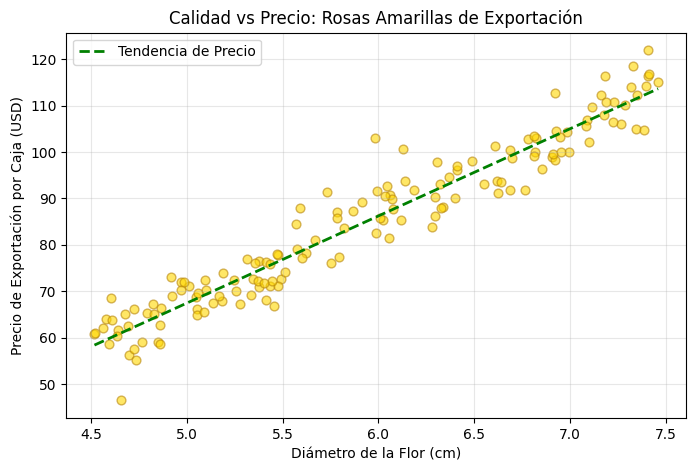

La línea verde confirma la tendencia: a mayor diámetro de la flor, mayor es el precio en el mercado internacional.


In [15]:
## 1.3 - Visualización de la tendencia comercial
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, color='gold', edgecolor='darkgoldenrod', s=40)

# Línea de tendencia comercial (valoración ideal)
m, b = np.polyfit(X.flatten(), y.flatten(), 1)
x_linea = np.linspace(X.min(), X.max(), 100)
plt.plot(x_linea, m * x_linea + b, color='green', linewidth=2,
         linestyle='--', label='Tendencia de Precio')

plt.xlabel('Diámetro de la Flor (cm)')
plt.ylabel('Precio de Exportación por Caja (USD)')
plt.title('Calidad vs Precio: Rosas Amarillas de Exportación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("La línea verde confirma la tendencia: a mayor diámetro de la flor, mayor es el precio en el mercado internacional.")

In [16]:
## 1.4 - División y normalización de los datos
# Separamos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizamos para que la red neuronal aprenda de una forma más eficiente
# Esto lleva todos los valores a media 0 y desviación estándar 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (120, 1)
Datos de prueba: (30, 1)


# **2 - Modelo bien entrenado**

Un modelo bien entrenado va a aprender la tendencia general sin memorizar los datos. En nuestro caso, la red debe entender que a mayor diámetro de la flor, mayor es el precio, sin obsesionarse con cada variación puntual del mercado.
Aqui usaremos una función para construir el modelo y así reutilizarla en los 3 experimentos, lo único que cambiará entre ellos es la cantidad de épocas.

## **2.1 - Construcción del modelo**

Aquí definimos la arquitectura de la red neuronal dentro de una función reutilizable. Usaremos tres capas ocultas con activación ReLU y una capa de salida sin activación porque estamos prediciendo un valor numérico continuo, no clasificando.

In [30]:
# Definimos la función que construye el modelo, la usaremos en los 3 experimentos
def crear_modelo():
    modelo = keras.Sequential([
        # Capa 1: recibe el diámetro y detecta patrones básicos
        keras.layers.Dense(64, activation='relu', input_shape=(1,)),
        # Capa 2: refina los patrones encontrados
        keras.layers.Dense(32, activation='relu'),
        # Capa 3: ajuste fino antes de la salida
        keras.layers.Dense(16, activation='relu'),
        # Salida: devuelve el precio estimado en USD
        keras.layers.Dense(1)
    ])
    # Adam como optimizador y MSE como función de pérdida para regresión
    modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return modelo

# Creamos una instancia para ver la estructura del modelo
modelo_prueba = crear_modelo()
modelo_prueba.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

## **2.2 - Entrenamiento**

Aquí vamos a entrenar el modelo con 100 épocas, es lo suficiente para aprender la relación entre diámetro y precio sin memorizar las fluctuaciones del mercado.

In [38]:
# Creamos una instancia limpia del modelo usando la función definida
modelo_bueno = crear_modelo()

# Entrenamos el modelo con los datos de entrenamiento
historia_bueno = modelo_bueno.fit(
    X_train, y_train,
    epochs=100,                        # 100 ciclos de entrenamiento
    batch_size=32,                     # Procesa 32 muestras por paso
    validation_data=(X_test, y_test),  # Validamos con datos que el modelo no ha visto
    verbose=1                          
)

print("Entrenamiento completado.")

Epoch 1/100


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 7593.5967 - mae: 85.4337 - val_loss: 6905.5796 - val_mae: 81.3254
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7572.7573 - mae: 85.3068 - val_loss: 6883.2271 - val_mae: 81.1805
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 7552.8135 - mae: 85.1817 - val_loss: 6859.7959 - val_mae: 81.0264
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7531.7988 - mae: 85.0495 - val_loss: 6835.6768 - val_mae: 80.8701
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7509.5894 - mae: 84.9126 - val_loss: 6810.5254 - val_mae: 80.7093
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7485.5249 - mae: 84.7657 - val_loss: 6782.2744 - val_mae: 80.5292
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 7457.7261 - mae: 84.5965 - val_loss: 6749.3374 - val_mae: 80.3206
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7425.2007 - mae: 84.4000 - val_loss: 6711.5454 - val_mae: 80.0820
Epoch 9/100
4/4 ━━━━

## **2.3 - Evaluación del modelo**

En este apartado medimos qué tan precisas son las predicciones del modelo usando los datos de prueba que nunca vio durante el entrenamiento.

In [39]:
# Generamos las predicciones con los datos de prueba
predicciones_bueno = modelo_bueno.predict(X_test).flatten()

# Calculamos el error promedio y el coeficiente de determinación
mse_bueno = mean_squared_error(y_test, predicciones_bueno)  # Error en la predicción del precio
r2_bueno = r2_score(y_test, predicciones_bueno)             # Qué tanto explica la variación del precio

print(f"MSE: {mse_bueno:.4f}")
print(f"R2:  {r2_bueno:.4f}")
print(f"\nEl modelo explica el {r2_bueno*100:.1f}% de la variabilidad del precio de exportación")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
MSE: 37.4931
R2:  0.8721

El modelo explica el 87.2% de la variabilidad del precio de exportación


## **2.4 - Visualización de resultados**

Aquí se grafica las curvas de aprendizaje y la comparación entre los precios reales y predichos. EN el caso de que el modelo aprendió bien, ambas curvas deben bajar juntas y los puntos deben alinearse cerca de la línea verde.

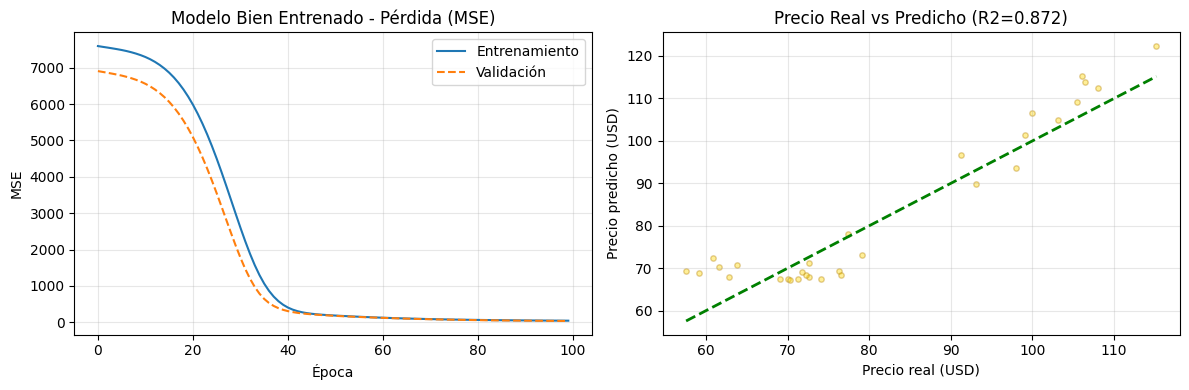

Las curvas bajan juntas y se estabilizan: el modelo aprendió la tendencia comercial sin memorizar el ruido del mercado.


In [40]:
plt.figure(figsize=(12, 4))

# Gráfica 1: curvas de pérdida durante el entrenamiento y validación
plt.subplot(1, 2, 1)
plt.plot(historia_bueno.history['loss'], label='Entrenamiento')
plt.plot(historia_bueno.history['val_loss'], label='Validación', linestyle='--')
plt.title('Modelo Bien Entrenado - Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica 2: precio real vs precio predicho por el modelo
plt.subplot(1, 2, 2)
plt.scatter(y_test, predicciones_bueno, alpha=0.4, s=15, color='gold', edgecolor='darkgoldenrod')
# Línea verde: representa la predicción perfecta
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', linewidth=2)
plt.title(f'Precio Real vs Predicho (R2={r2_bueno:.3f})')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Las curvas bajan juntas y se estabilizan: el modelo aprendió la tendencia comercial sin memorizar el ruido del mercado.")

# **3 - Modelo con subentrenamiento (Underfitting)**

Un modelo subentrenado es aquel que no tuvo el suficiente tiempo para aprender el patrón de los datos. En nuestro caso, la red neuronal apenas alcanza a ver unos pocos ciclos de entrenamiento, por lo que este no logra entender la relación entre el diámetro de la flor y el precio de exportación, asi fallando incluso con datos que ya conoce.

## **3.1 - Entrenamiento con pocas épocas**
Aquí vamos a reutilizar la misma arquitectura del modelo anterior, pero esta vez solo le damos 5 épocas, demasiado poco para que logre aprender cualquier patrón significativo.

In [41]:
# Creamos una instancia limpia del mismo modelo
modelo_sub = crear_modelo()

# Entrenamos con solo 5 épocas, insuficiente para aprender la tendencia comercial
historia_sub = modelo_sub.fit(
    X_train, y_train,
    epochs=5,                          # Muy pocas épocas, el modelo no alcanza a aprender
    batch_size=32,                     # Procesa 32 muestras por paso
    validation_data=(X_test, y_test),  # Validamos con datos no vistos
    verbose=1                         
)

print("Entrenamiento completado.")

Epoch 1/5


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 7615.8799 - mae: 85.5564 - val_loss: 6934.5449 - val_mae: 81.4920
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7603.9512 - mae: 85.4804 - val_loss: 6923.6475 - val_mae: 81.4165
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 7596.2456 - mae: 85.4286 - val_loss: 6917.6436 - val_mae: 81.3749
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7591.4019 - mae: 85.3970 - val_loss: 6911.6929 - val_mae: 81.3348
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7585.5376 - mae: 85.3595 - val_loss: 6903.7603 - val_mae: 81.2833
Entrenamiento completado.


## **3.2 - Evaluación**
Aquí vamos a comparar las métricas del modelo subentrenado con las del modelo bien entrenado. En si se espera un MSE mucho más alto y un R2 considerablemente más bajo.

In [42]:
# Generamos las predicciones con los datos de prueba
predicciones_sub = modelo_sub.predict(X_test).flatten()

# Calculamos las métricas de evaluación
mse_sub = mean_squared_error(y_test, predicciones_sub)  # Error esperado alto por falta de aprendizaje
r2_sub = r2_score(y_test, predicciones_sub)             # R2 bajo indica que no explica bien la variación

print(f"MSE: {mse_sub:.4f}")
print(f"R2:  {r2_sub:.4f}")
print(f"\nEl modelo solo explica el {r2_sub*100:.1f}% de la variabilidad del precio de exportación")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
MSE: 6903.7606
R2:  -22.5478

El modelo solo explica el -2254.8% de la variabilidad del precio de exportación


## **3.3 - Visualización de resultados**
Aquí vamos a ver cómo las curvas de pérdida que no logran estabilizarse y los puntos del scatter se alejan bastante de la línea verde, esto evidenciando que el modelo no llego a aprender la tendencia.

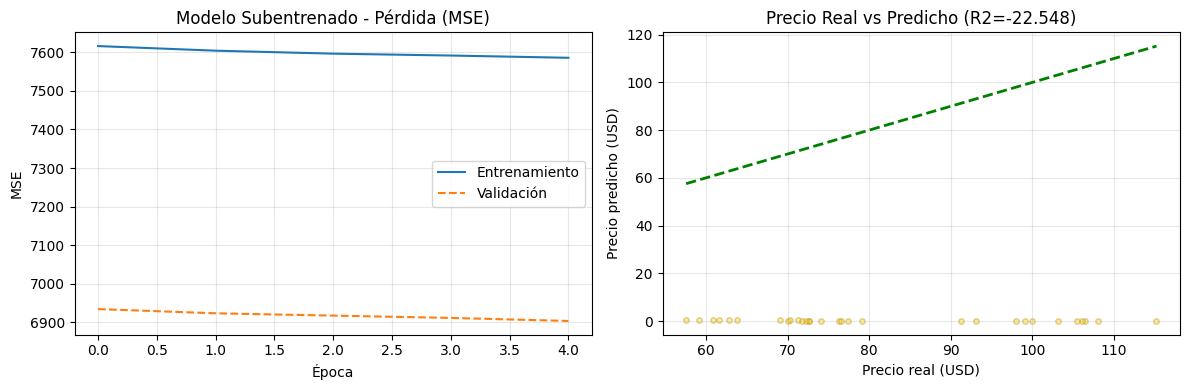

Las curvas casi no bajan y el MSE se mantiene muy alto: el modelo no tuvo suficientes épocas para aprender la relación entre el diámetro de la flor y el precio de exportación.


In [75]:
plt.figure(figsize=(12, 4))

# Gráfica 1: curvas de pérdida, se espera que no bajen lo suficiente
plt.subplot(1, 2, 1)
plt.plot(historia_sub.history['loss'], label='Entrenamiento')
plt.plot(historia_sub.history['val_loss'], label='Validación', linestyle='--')
plt.title('Modelo Subentrenado - Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica 2: precio real vs precio predicho, los puntos se alejan de la línea ideal
plt.subplot(1, 2, 2)
plt.scatter(y_test, predicciones_sub, alpha=0.4, s=15, color='gold', edgecolor='darkgoldenrod')
# Línea verde: representa la predicción perfecta
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', linewidth=2)
plt.title(f'Precio Real vs Predicho (R2={r2_sub:.3f})')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Las curvas casi no bajan y el MSE se mantiene muy alto: el modelo no tuvo suficientes épocas para aprender la relación entre el diámetro de la flor y el precio de exportación.")

# **4 - Modelo con sobreentrenamiento (Overfitting)**
Un modelo sobreentrenado va a memorizar los datos de entrenamiento en lugar de aprender la tendencia general. En nuestro caso, vamos a usar una red mucho más grande y un batch muy pequeño para forzar que el modelo memorice cada variación de precio, perdiendo así su capacidad de predecir los precios nuevos.

## **4.1 - Construcción del modelo sobreentrenado**
Aquí se define una arquitectura más grande que la anterior, con más capas y más neuronas. Tanta capacidad para solo 150 registros es lo que provoca la memorización.

In [67]:
# Definimos una red más grande para forzar el overfitting
def crear_modelo_over():
    modelo = keras.Sequential([
        # Red sobredimensionada para 150 registros, esto provoca memorización
        keras.layers.Dense(256, activation='relu', input_shape=(1,)),  # Capa 1: 256 neuronas
        keras.layers.Dense(256, activation='relu'),                     # Capa 2: 256 neuronas
        keras.layers.Dense(128, activation='relu'),                     # Capa 3: 128 neuronas
        keras.layers.Dense(128, activation='relu'),                     # Capa 4: 128 neuronas
        keras.layers.Dense(64, activation='relu'),                      # Capa 5: 64 neuronas
        keras.layers.Dense(1)                                           # Salida: precio en USD
    ])
    # Mismo compilador que los modelos anteriores para comparar en igualdad
    modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return modelo

# Mostramos la estructura del modelo
modelo_prueba_over = crear_modelo_over()
modelo_prueba_over.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_93 (Dense)                │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,033 (484.50 KB)

 Trainable params: 124,033 (484.50 KB)

 Non-trainable params: 0 (0.00 B)

## **4.2 - Entrenamiento con demasiadas épocas**
Aquí vamos a combinar una red grande con un batch muy pequeño. Esto hace que el modelo actualice sus pesos demasiadas veces por época, asi forzándolo a memorizar cada registro en lugar de aprender la tendencia.

In [68]:
# Creamos una instancia del modelo sobreentrenado
modelo_over = crear_modelo_over()

# Batch de 2 y 800 épocas fuerzan la memorización de los datos
historia_over = modelo_over.fit(
    X_train, y_train,
    epochs=800,                        # Épocas suficientes para memorizar
    batch_size=2,                      # Batch muy pequeño, actualiza pesos demasiadas veces
    validation_data=(X_test, y_test),  # Validamos con datos no vistos
    verbose=1                         
)

print("Entrenamiento completado.")

Epoch 1/800


60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4524.8311 - mae: 59.4762 - val_loss: 511.4165 - val_mae: 18.3563
Epoch 2/800
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 441.4072 - mae: 17.5043 - val_loss: 176.5374 - val_mae: 11.0243
Epoch 3/800
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 149.3959 - mae: 9.8147 - val_loss: 53.7969 - val_mae: 6.3171
Epoch 4/800
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 69.2036 - mae: 6.5964 - val_loss: 19.5459 - val_mae: 3.7672
Epoch 5/800
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 49.2609 - mae: 5.5066 - val_loss: 11.3137 - val_mae: 2.7339
Epoch 6/800
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 46.9952 - mae: 5.3970 - val_loss: 10.2237 - val_mae: 2.6520
Epoch 7/800
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.2302 - mae: 5.4995 - val_loss: 11.8111 - val_mae: 2.9009
Epoch 8/800
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 49.2916 - mae: 5.5710 - val_loss: 15.3848 - val_mae: 3.3171
Epoch 9/800
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

## **4.3 - Evaluación**
Aquí vamos a ver que a pesar de tanto entrenamiento el modelo no mejora en datos nuevos, asi evidenciando que memorizó en lugar de aprender.

In [69]:
# Generamos las predicciones con los datos de prueba
predicciones_over = modelo_over.predict(X_test).flatten()

# Calculamos las métricas de evaluación
mse_over = mean_squared_error(y_test, predicciones_over)  # Error en datos nuevos
r2_over = r2_score(y_test, predicciones_over)             # R2 bajo a pesar de tanto entrenamiento

print(f"MSE: {mse_over:.4f}")
print(f"R2:  {r2_over:.4f}")
print(f"\nEl modelo solo explica el {r2_over*100:.1f}% de la variabilidad del precio de exportación")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
MSE: 22.7747
R2:  0.9223

El modelo solo explica el 92.2% de la variabilidad del precio de exportación


## **4.4 - Visualización de resultados**
Aquí veremos que aunque las curvas parecen seguirse, la validación va a presentar pequeñas oscilaciones y estas no se estabiliza de forma limpia. El scatter muestra más dispersión que el modelo bien entrenado, asi confirmando que el modelo perdió algo de capacidad predictiva.

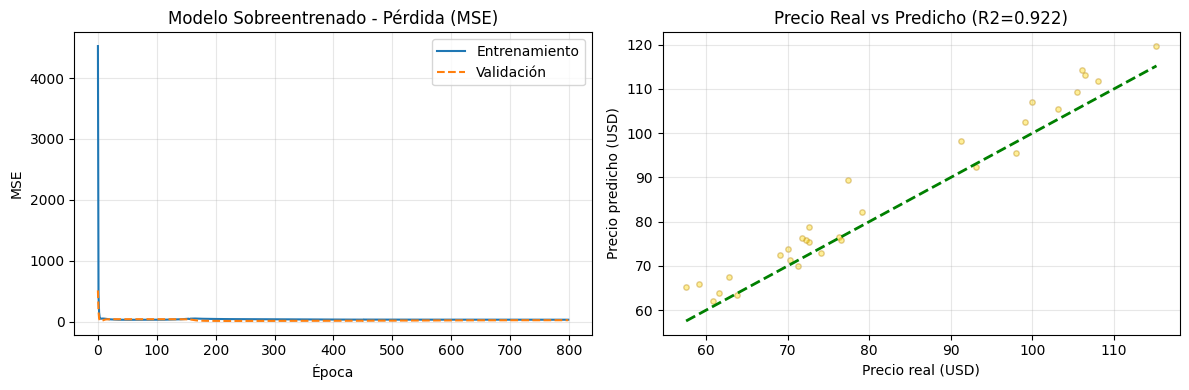

Aunque las curvas parecen seguirse, la curva de validación presenta oscilaciones que no logran estabilizarse como en el modelo bien entrenado, y el R2 es menor, señal de que el modelo está memorizando en lugar de generalizar.


In [70]:
plt.figure(figsize=(12, 4))

# Gráfica 1: la curva de validación se separa de la de entrenamiento
plt.subplot(1, 2, 1)
plt.plot(historia_over.history['loss'], label='Entrenamiento')
plt.plot(historia_over.history['val_loss'], label='Validación', linestyle='--')
plt.title('Modelo Sobreentrenado - Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica 2: los puntos se dispersan de la línea ideal por memorizar el ruido
plt.subplot(1, 2, 2)
plt.scatter(y_test, predicciones_over, alpha=0.4, s=15, color='gold', edgecolor='darkgoldenrod')
# Línea verde: representa la predicción perfecta
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', linewidth=2)
plt.title(f'Precio Real vs Predicho (R2={r2_over:.3f})')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Aunque las curvas parecen seguirse, la curva de validación presenta oscilaciones que no logran estabilizarse como en el modelo bien entrenado, y el R2 es menor, señal de que el modelo está memorizando en lugar de generalizar.")

# **5 - Comparación de los tres modelos**
Se va a comparar los tres modelos entrenados para visualizar claramente las diferencias que existen entre un modelo subentrenado, uno bien entrenado y uno sobreentrenado, tanto en sus métricas numéricas como en sus curvas de aprendizaje.

## **5.1 - Comparación de métricas**
Aquí vamos a resumir los resultados de los tres modelos en una tabla para ver de forma directa cuál aprendió mejor la tendencia comercial.

In [71]:
# Resumen de métricas de los tres modelos
print("=" * 50)
print(f"{'Modelo':<20} {'MSE':>10} {'R2':>10}")
print("=" * 50)
print(f"{'Subentrenado':<20} {mse_sub:>10.4f} {r2_sub:>10.4f}")
print(f"{'Bien entrenado':<20} {mse_bueno:>10.4f} {r2_bueno:>10.4f}")
print(f"{'Sobreentrenado':<20} {mse_over:>10.4f} {r2_over:>10.4f}")
print("=" * 50)

Modelo                      MSE         R2
Subentrenado          6903.7606   -22.5478
Bien entrenado          37.4931     0.8721
Sobreentrenado          22.7747     0.9223


## **5.2 - Comparación de curvas de aprendizaje**
Aquí vamos a graficar las curvas de pérdida de los tres modelos juntas para ver visualmente cómo cada una de ellas aprendió de forma distinta.

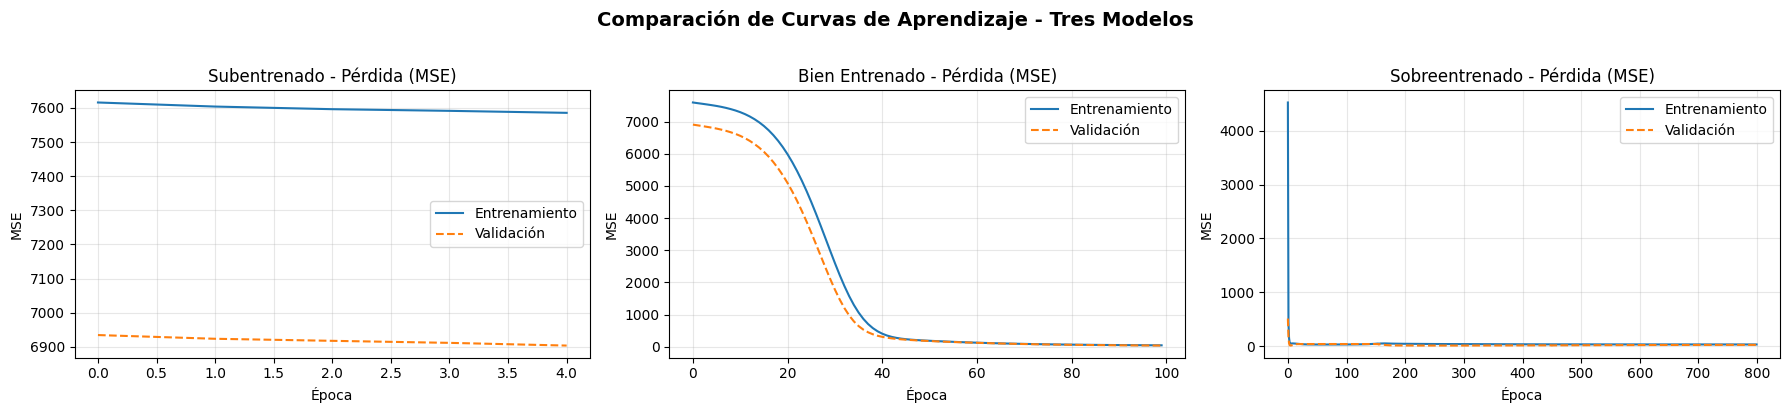

El modelo subentrenado casi no baja su MSE quedándose plano cerca de 7000, el bien entrenado baja y se estabiliza de forma limpia, y el sobreentrenado presenta oscilaciones en la validación que revelan memorización.


In [76]:
plt.figure(figsize=(18, 4))
plt.suptitle('Comparación de Curvas de Aprendizaje - Tres Modelos', fontsize=14, fontweight='bold', y=1.02)

# Curvas del modelo subentrenado
plt.subplot(1, 3, 1)
plt.plot(historia_sub.history['loss'], label='Entrenamiento')
plt.plot(historia_sub.history['val_loss'], label='Validación', linestyle='--')
plt.title('Subentrenado - Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

# Curvas del modelo bien entrenado
plt.subplot(1, 3, 2)
plt.plot(historia_bueno.history['loss'], label='Entrenamiento')
plt.plot(historia_bueno.history['val_loss'], label='Validación', linestyle='--')
plt.title('Bien Entrenado - Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

# Curvas del modelo sobreentrenado
plt.subplot(1, 3, 3)
plt.plot(historia_over.history['loss'], label='Entrenamiento')
plt.plot(historia_over.history['val_loss'], label='Validación', linestyle='--')
plt.title('Sobreentrenado - Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("El modelo subentrenado casi no baja su MSE quedándose plano cerca de 7000, el bien entrenado baja y se estabiliza de forma limpia, y el sobreentrenado presenta oscilaciones en la validación que revelan memorización.")


## **5.3 - Comparación de predicciones**
Aquí graficamos los tres scatters juntos para ver visualmente qué tan cerca o lejos estuvieron las predicciones de cada modelo respecto al precio real.

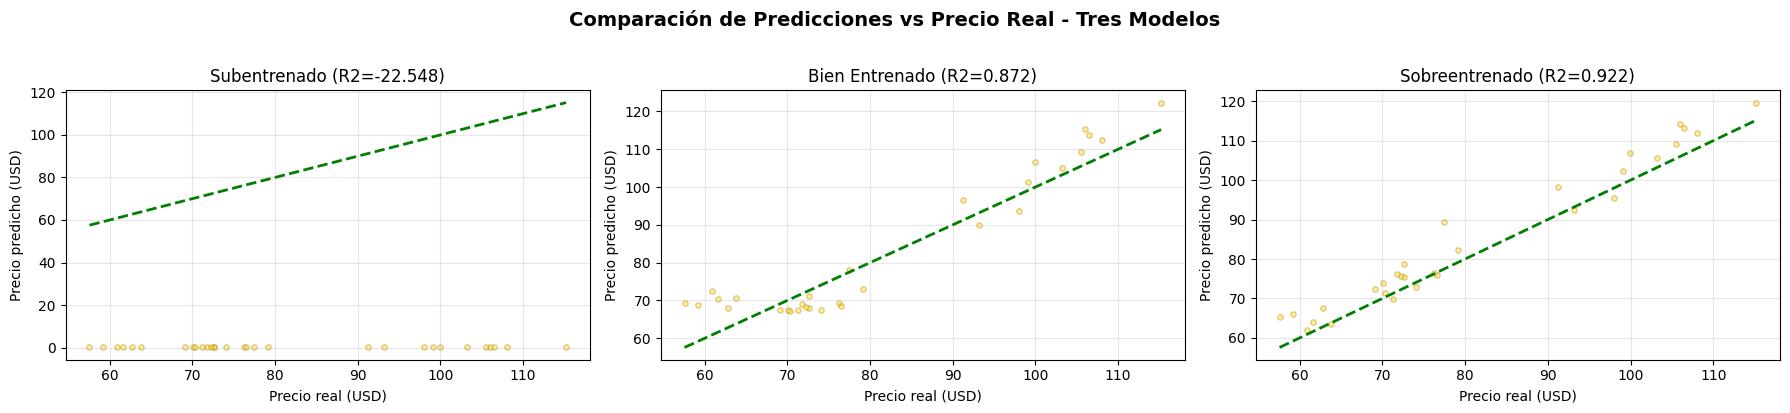

El modelo bien entrenado es el que mejor predice el precio de exportación, logrando el mayor R2 y el menor error entre los tres.


In [77]:
plt.figure(figsize=(18, 4))
plt.suptitle('Comparación de Predicciones vs Precio Real - Tres Modelos', fontsize=14, fontweight='bold', y=1.02)

# Predicciones del modelo subentrenado
plt.subplot(1, 3, 1)
plt.scatter(y_test, predicciones_sub, alpha=0.4, s=15, color='gold', edgecolor='darkgoldenrod')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', linewidth=2)
plt.title(f'Subentrenado (R2={r2_sub:.3f})')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.grid(True, alpha=0.3)

# Predicciones del modelo bien entrenado
plt.subplot(1, 3, 2)
plt.scatter(y_test, predicciones_bueno, alpha=0.4, s=15, color='gold', edgecolor='darkgoldenrod')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', linewidth=2)
plt.title(f'Bien Entrenado (R2={r2_bueno:.3f})')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.grid(True, alpha=0.3)

# Predicciones del modelo sobreentrenado
plt.subplot(1, 3, 3)
plt.scatter(y_test, predicciones_over, alpha=0.4, s=15, color='gold', edgecolor='darkgoldenrod')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', linewidth=2)
plt.title(f'Sobreentrenado (R2={r2_over:.3f})')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("El modelo bien entrenado es el que mejor predice el precio de exportación, logrando el mayor R2 y el menor error entre los tres.")

# **6 - Conclusiones**
A lo largo de este ejercicio, pudimos comprobar de primera mano que una red neuronal no es magia; su éxito siempre va a depender totalmente de cómo gestionemos su aprendizaje. Llevando la teoría al escenario real de la exportación de rosas amarillas, nos encontramos con tres escenarios distintos:

* **El modelo subentrenado:** Este no tuvo el suficiente tiempo para aprender la relación entre el diámetro de la flor y el precio, dandonos un resultando en predicciones pobres que no siguen la tendencia comercial. Sus curvas de pérdida no bajaron lo suficiente y su R2 fue el más bajo de los tres.

* **El modelo bien entrenado:** Se encontró el balance ideal, este aprendió que a mayor diámetro mayor es el precio sin memorizar las fluctuaciones del mercado. Sus curvas bajaron juntas y se estabilizaron, asi obteniendo el mejor R2 y el menor error de predicción.

* **El modelo sobreentrenado:** En este caso tuvo demasiada capacidad para un dataset tan pequeño, lo que lo llevó a memorizar variaciones que no representan una tendencia real. Aunque sus curvas llegan a parecer estables, la validación presenta oscilaciones y su R2 es menor que el del modelo bien entrenado.

In [78]:
# Tabla resumen final
print("=" * 55)
print(f"{'Modelo':<20} {'MSE':>10} {'R2':>10} {'Resultado'}")
print("=" * 55)
print(f"{'Subentrenado':<20} {mse_sub:>10.4f} {r2_sub:>10.4f}  Aprende poco")
print(f"{'Bien entrenado':<20} {mse_bueno:>10.4f} {r2_bueno:>10.4f}  Mejor modelo")
print(f"{'Sobreentrenado':<20} {mse_over:>10.4f} {r2_over:>10.4f}  Memoriza")
print("=" * 55)
print("\nEl modelo bien entrenado es el más útil para predecir el precio de exportación de rosas amarillas en el mercado internacional.")

Modelo                      MSE         R2 Resultado
Subentrenado          6903.7606   -22.5478  Aprende poco
Bien entrenado          37.4931     0.8721  Mejor modelo
Sobreentrenado          22.7747     0.9223  Memoriza

El modelo bien entrenado es el más útil para predecir el precio de exportación de rosas amarillas en el mercado internacional.
